# reconnaissance image 

## chargment des données 

In [1]:
import struct
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# 1. FONCTIONS DE CHARGEMENT IDX
# =========================================================
def load_idx_images(path):
    with open(path, "rb") as f:
        magic, num, rows, cols = struct.unpack(">IIII", f.read(16))
        images = np.frombuffer(f.read(), dtype=np.uint8)
        images = images.reshape(num, rows, cols)
    return images

def load_idx_labels(path):
    with open(path, "rb") as f:
        magic, num = struct.unpack(">II", f.read(8))
        labels = np.frombuffer(f.read(), dtype=np.uint8)
    return labels

# =========================================================
# 2. CHARGEMENT
# =========================================================
# =========================================================
# 2. CHARGEMENT
# =========================================================

base_path = r"C:\Users\louis\OneDrive - ECAM\ECAM\IA\labo\student_dataset\image_data"

X_train = load_idx_images(base_path + r"\train-images-idx3-ubyte")
y_train = load_idx_labels(base_path + r"\train-labels-idx1-ubyte")

X_test = load_idx_images(base_path + r"\test-images-idx3-ubyte")
y_test = load_idx_labels(base_path + r"\test-labels-idx1-ubyte")

# Correction orientation
X_train = np.transpose(X_train, (0, 2, 1))
X_test = np.transpose(X_test, (0, 2, 1))

print("Train images :", X_train.shape)
print("Test images  :", X_test.shape)

print("Train images :", X_train.shape)
print("Train labels :", y_train.shape)
print("Test images  :", X_test.shape)
print("Test labels  :", y_test.shape)
print("Nombre de classes :", len(np.unique(y_train)))

""" 
on va charger les images pour les rendres exploitables. 
A noter que nous aurons 62 classes, chiffres, Majuscules et minuscules.

"""


Train images : (697932, 28, 28)
Test images  : (116323, 28, 28)
Train images : (697932, 28, 28)
Train labels : (697932,)
Test images  : (116323, 28, 28)
Test labels  : (116323,)
Nombre de classes : 62


' \non va charger les images pour les rendres exploitables. \nA noter que nous aurons 62 classes, chiffres, Majuscules et minuscules.\n\n'

## mapping label

In [2]:
# =========================================================
# 3. CHARGEMENT DU MAPPING
# =========================================================
mapping_path = base_path + r"\mapping.txt"

mapping = {}
with open(mapping_path, "r", encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        idx_str, ascii_str = line.split()
        mapping[int(idx_str)] = chr(int(ascii_str))

print(mapping[0], mapping[10], mapping[36])  # ex: 0, A, a



print("Nombre d'images train :", len(X_train))
print("Nombre d'images test  :", len(X_test))
print("Nombre de classes :", len(np.unique(y_train)))
print("Shape image :", X_train[0].shape)

"""
associe les images avec leur classes
"""

0 A a
Nombre d'images train : 697932
Nombre d'images test  : 116323
Nombre de classes : 62
Shape image : (28, 28)


'\nassocie les images avec leur classes\n'

## Bloc 3 — visualisation

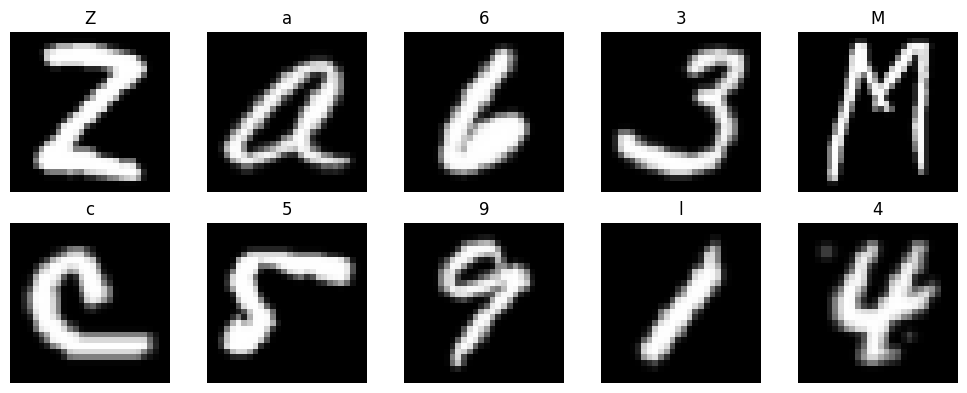

'\nverification rapide du mon mappage\n'

In [3]:
# =========================================================
# 4. VISUALISATION
# =========================================================
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(X_train[i], cmap="gray")
    plt.title(mapping[y_train[i]])
    plt.axis("off")
plt.tight_layout()
plt.show()

"""
verification rapide du mon mappage
"""

## Bloc 4 - prétraitement 

In [4]:
# =========================================================
# 5. NORMALISATION
# =========================================================
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

# Pour CNN : ajout du canal
X_train_cnn = X_train[..., np.newaxis]
X_test_cnn = X_test[..., np.newaxis]

print("Shape CNN train :", X_train_cnn.shape)
print("Shape CNN test  :", X_test_cnn.shape)

"""
les pixels devienent binaire et ajout d'une dimension pour assurer le vecteur attendue par le CNN
"""

Shape CNN train : (697932, 28, 28, 1)
Shape CNN test  : (116323, 28, 28, 1)


"\nles pixels devienent binaire et ajout d'une dimension pour assurer le vecteur attendue par le CNN\n"

## modele MLP

In [5]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# =========================================================
# 6. BASELINE OCR : MLP SIMPLE
# =========================================================
X_train_flat = X_train.reshape(len(X_train), -1)
X_test_flat = X_test.reshape(len(X_test), -1)

#MLP ne peux pas comprendre directement les images 2D, on doit lui donner sous forme de vecteur

mlp_ocr = MLPClassifier(
    hidden_layer_sizes=(128,), # nombre de neurones et 1 seul couches
    max_iter=20, # nombre maximale de passage 
    random_state=42 #
)
#parametre du modele, 

mlp_ocr.fit(X_train_flat, y_train)

y_pred_mlp = mlp_ocr.predict(X_test_flat)

acc_mlp = accuracy_score(y_test, y_pred_mlp)

print("===== MLP OCR =====")
print("Accuracy :", acc_mlp)

"""
modele MLP
"""

C:\Users\louis\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(


===== MLP OCR =====
Accuracy : 0.8389742355338153


'\nmodele MLP\n'

## modele CNN simple 

In [6]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import accuracy_score

# =========================================================
# 7. CNN SIMPLE
# =========================================================
cnn_model = keras.Sequential([
    layers.Input(shape=(X_train_cnn.shape[1], X_train_cnn.shape[2], 1)),
    
    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    
    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(62, activation="softmax")
])

cnn_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

early_stop = keras.callbacks.EarlyStopping(
    patience=3,
    restore_best_weights=True
)

history = cnn_model.fit(
    X_train_cnn, y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=128,
    callbacks=[early_stop],
    verbose=1
)

# =========================================================
# 8. EVALUATION CNN
# =========================================================
test_loss, test_acc = cnn_model.evaluate(X_test_cnn, y_test, verbose=0)

print("===== CNN OCR =====")
print("Test accuracy :", test_acc)

Epoch 1/10
4363/4363 ━━━━━━━━━━━━━━━━━━━━ 92s 21ms/step - accuracy: 0.7871 - loss: 0.6704 - val_accuracy: 0.8465 - val_loss: 0.4287
Epoch 2/10
4363/4363 ━━━━━━━━━━━━━━━━━━━━ 148s 22ms/step - accuracy: 0.8387 - loss: 0.4662 - val_accuracy: 0.8551 - val_loss: 0.4002
Epoch 3/10
4363/4363 ━━━━━━━━━━━━━━━━━━━━ 146s 23ms/step - accuracy: 0.8468 - loss: 0.4331 - val_accuracy: 0.8613 - val_loss: 0.3808
Epoch 4/10
4363/4363 ━━━━━━━━━━━━━━━━━━━━ 139s 22ms/step - accuracy: 0.8520 - loss: 0.4133 - val_accuracy: 0.8600 - val_loss: 0.3810
Epoch 5/10
4363/4363 ━━━━━━━━━━━━━━━━━━━━ 103s 24ms/step - accuracy: 0.8555 - loss: 0.4010 - val_accuracy: 0.8627 - val_loss: 0.3763
Epoch 6/10
4363/4363 ━━━━━━━━━━━━━━━━━━━━ 135s 22ms/step - accuracy: 0.8588 - loss: 0.3902 - val_accuracy: 0.8646 - val_loss: 0.3702
Epoch 7/10
4363/4363 ━━━━━━━━━━━━━━━━━━━━ 93s 21ms/step - accuracy: 0.8601 - loss: 0.3817 - val_accuracy: 0.8663 - val_loss: 0.3676
Epoch 8/10
4363/4363 ━━━━━━━━━━━━━━━━━━━━ 102s 23ms/step - accuracy: 0.

## comparaison 

In [7]:
import pandas as pd

results_ocr = pd.DataFrame({
    "Model": ["MLP OCR", "CNN OCR"],
    "Accuracy": [acc_mlp, test_acc]
})

print(results_ocr.sort_values(by="Accuracy", ascending=False).to_string(index=False))

  Model  Accuracy
CNN OCR  0.867636
MLP OCR  0.838974


## confusion

3636/3636 ━━━━━━━━━━━━━━━━━━━━ 17s 5ms/step


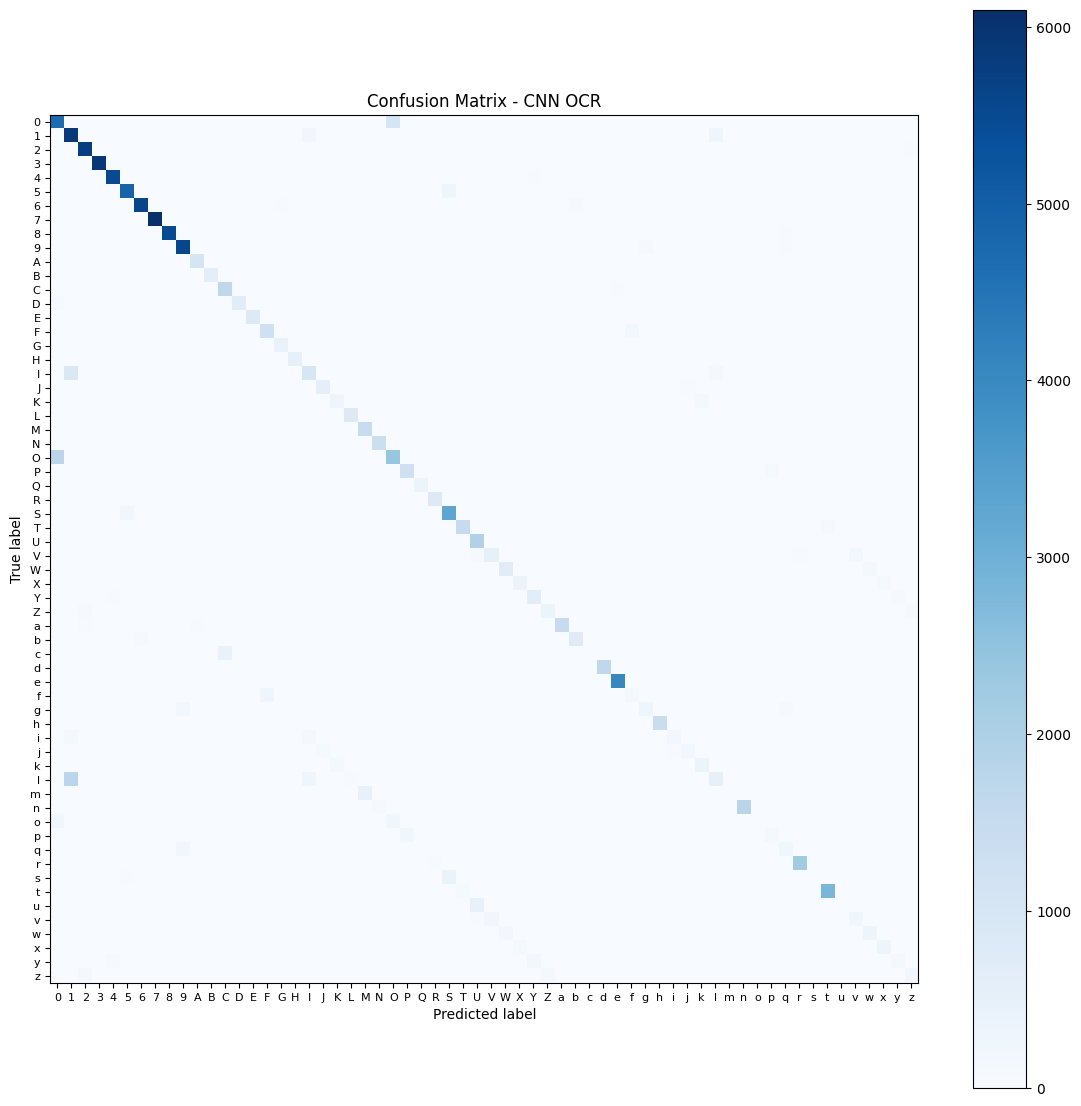

In [8]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Prédictions CNN
y_pred_cnn = np.argmax(cnn_model.predict(X_test_cnn), axis=1)

cm = confusion_matrix(y_test, y_pred_cnn)

# Liste des noms de classes dans l'ordre des indices
class_names = [mapping[i] for i in range(len(mapping))]

plt.figure(figsize=(14, 14))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(include_values=False, cmap="Blues", ax=plt.gca())
plt.title("Confusion Matrix - CNN OCR")
plt.xticks(fontsize=8)
plt.yticks(fontsize=8)
plt.show()

## erreurs 

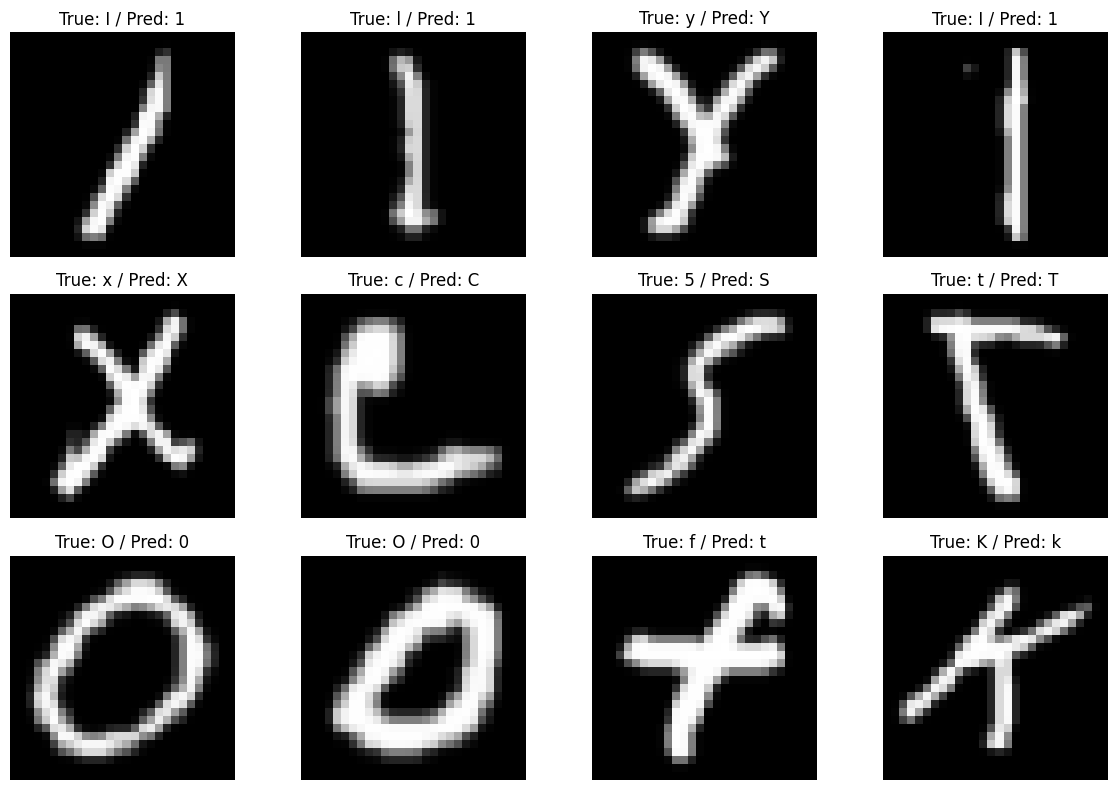

In [9]:
# =========================================================
# 9. EXEMPLES D'ERREURS
# =========================================================
misclassified = np.where(y_pred_cnn != y_test)[0]

plt.figure(figsize=(12, 8))
for i, idx in enumerate(misclassified[:12]):
    plt.subplot(3, 4, i+1)
    plt.imshow(X_test[idx], cmap="gray")
    true_char = mapping[y_test[idx]]
    pred_char = mapping[y_pred_cnn[idx]]
    plt.title(f"True: {true_char} / Pred: {pred_char}")
    plt.axis("off")
plt.tight_layout()
plt.show()

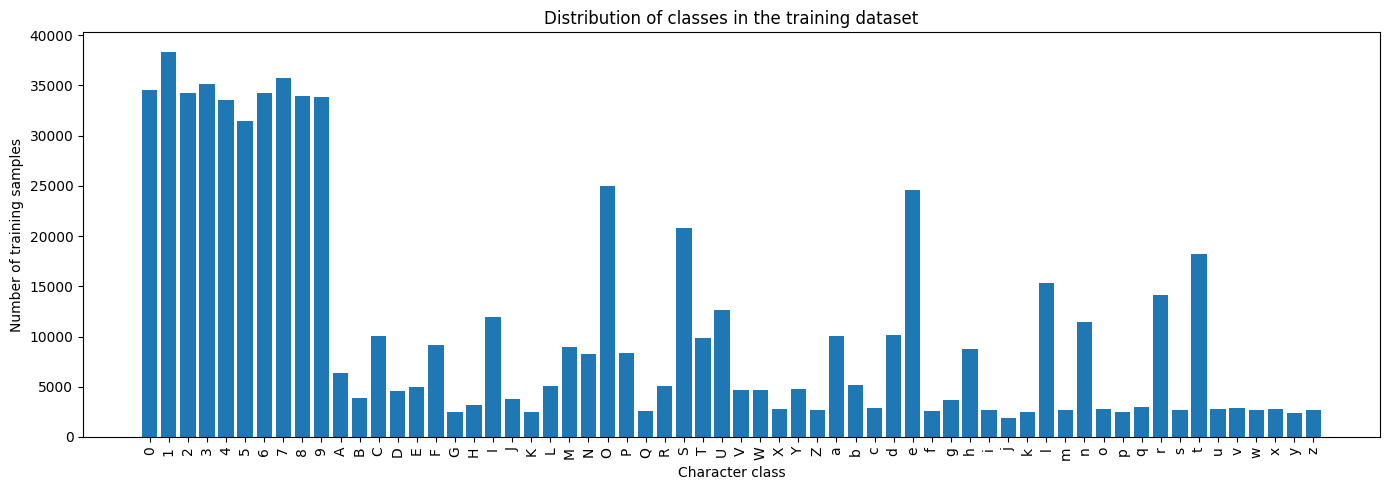

In [16]:
class_names = [mapping[i] for i in range(len(mapping))]

train_counts = pd.Series(y_train).value_counts().sort_index()
test_counts = pd.Series(y_test).value_counts().sort_index()

plt.figure(figsize=(14, 5))
plt.bar(class_names, train_counts.values)
plt.xlabel("Character class")
plt.ylabel("Number of training samples")
plt.title("Distribution of classes in the training dataset")
plt.xticks(rotation=90)
plt.tight_layout()
#plt.savefig("class_distribution_train.svg", bbox_inches="tight")
plt.show()

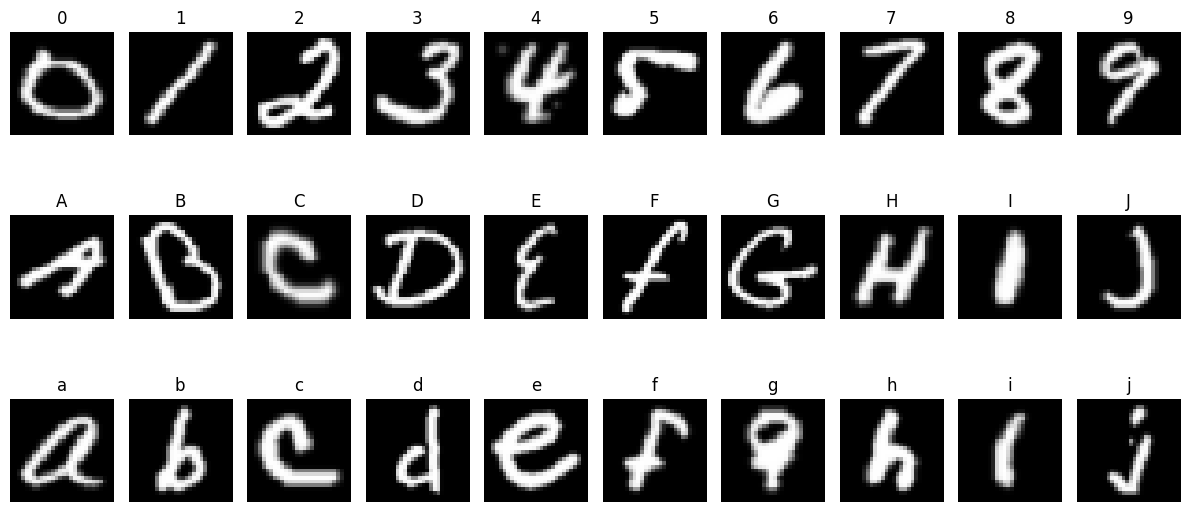

In [17]:
plt.figure(figsize=(12, 6))

selected_classes = list(range(0, 10)) + list(range(10, 20)) + list(range(36, 46))

for i, cls in enumerate(selected_classes):
    idx = np.where(y_train == cls)[0][0]
    plt.subplot(3, 10, i + 1)
    plt.imshow(X_train[idx], cmap="gray")
    plt.title(mapping[cls])
    plt.axis("off")

plt.tight_layout()
#plt.savefig("ocr_sample_images.svg", bbox_inches="tight")
plt.show()

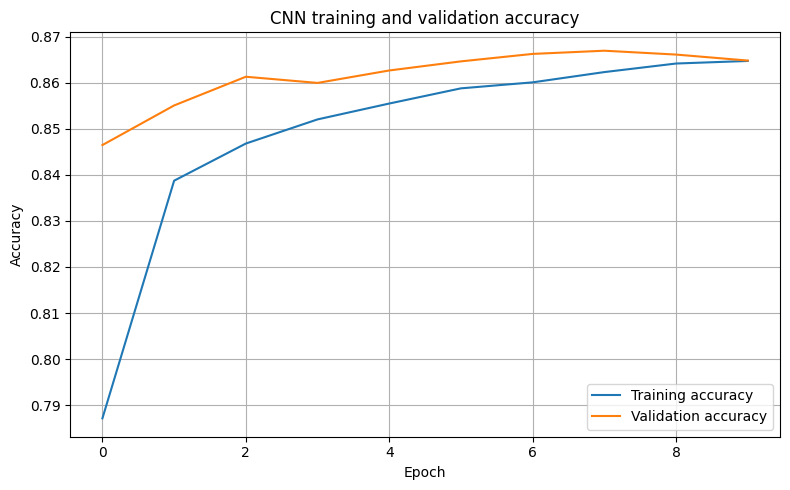

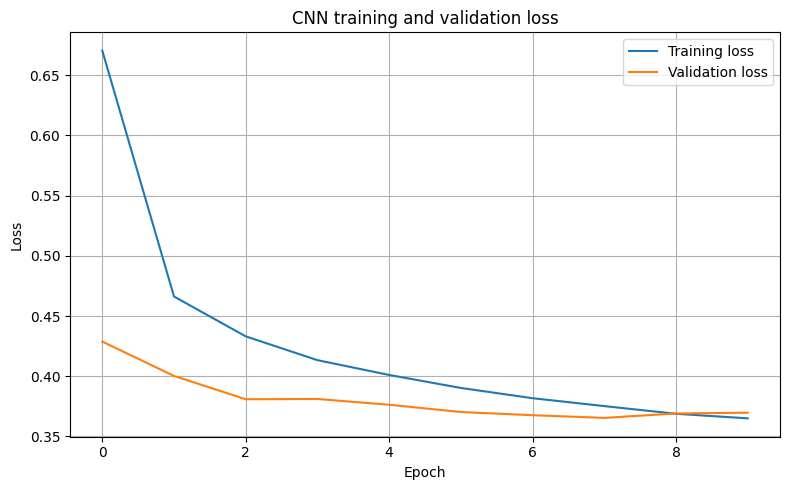

In [18]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Training accuracy")
plt.plot(history.history["val_accuracy"], label="Validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN training and validation accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()
#plt.savefig("cnn_accuracy_curve.svg", bbox_inches="tight")
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training loss")
plt.plot(history.history["val_loss"], label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN training and validation loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
#plt.savefig("cnn_loss_curve.svg", bbox_inches="tight")
plt.show()

In [13]:
results_ocr = pd.DataFrame({
    "Model": ["MLP", "CNN"],
    "Input representation": ["Flattened 28x28 image", "2D image with channel"],
    "Accuracy": [acc_mlp, test_acc]
})

results_ocr

,Model,Input representation,Accuracy
0,MLP,Flattened 28x28 image,0.838974
1,CNN,2D image with channel,0.867636


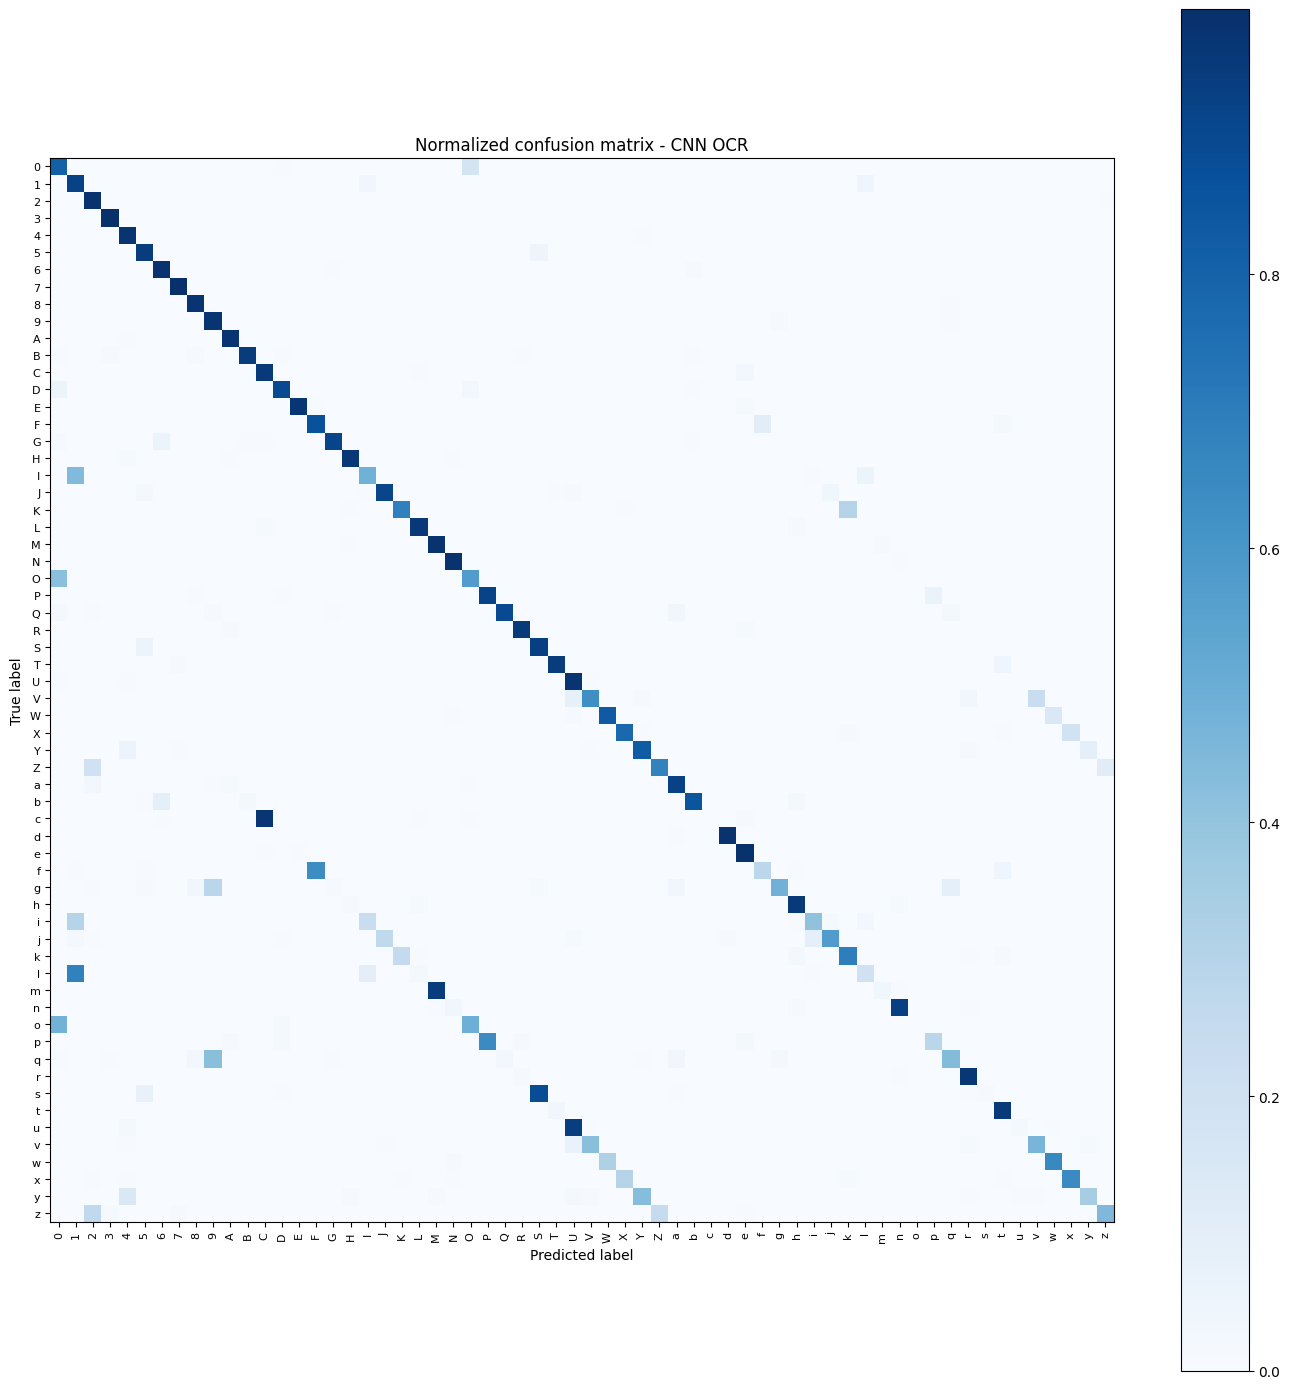

In [19]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm_norm = confusion_matrix(y_test, y_pred_cnn, normalize="true")

plt.figure(figsize=(14, 14))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=class_names)
disp.plot(include_values=False, cmap="Blues", ax=plt.gca())
plt.title("Normalized confusion matrix - CNN OCR")
plt.xticks(fontsize=8, rotation=90)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.savefig("cnn_confusion_matrix_normalized.svg", bbox_inches="tight")
plt.show()

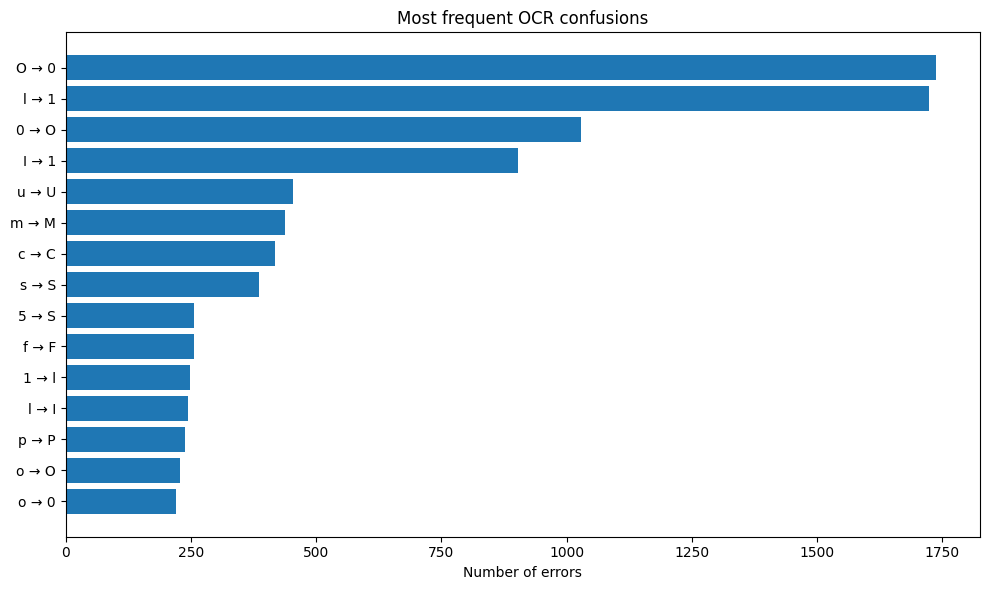

,True,Predicted,Count
1464,O,0,1738
2868,l,1,1723
23,0,O,1028
1099,I,1,902
3446,u,U,454
2950,m,M,438
2330,c,C,418
3322,s,S,386
332,5,S,256
2516,f,F,256


In [20]:
cm = confusion_matrix(y_test, y_pred_cnn)

errors = []

for true_label in range(len(class_names)):
    for pred_label in range(len(class_names)):
        if true_label != pred_label:
            errors.append({
                "True": class_names[true_label],
                "Predicted": class_names[pred_label],
                "Count": cm[true_label, pred_label]
            })

errors_df = pd.DataFrame(errors).sort_values(by="Count", ascending=False)
top_errors = errors_df.head(15)

plt.figure(figsize=(10, 6))
labels = top_errors["True"] + " → " + top_errors["Predicted"]
plt.barh(labels[::-1], top_errors["Count"][::-1])
plt.xlabel("Number of errors")
plt.title("Most frequent OCR confusions")
plt.tight_layout()
#plt.savefig("top_ocr_errors.svg", bbox_inches="tight")
plt.show()

top_errors

[]
